<a href="https://colab.research.google.com/github/Elsacred02/Progetto_AML_2025_2026/blob/main/Codice_progetto_AML_2025_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
# Import librerie

import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from google.colab import drive

In [36]:
# Scarica ultima versione dataset
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/sea_animals"
os.listdir(DATA_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['Sea Urchins',
 'Clams',
 'Dolphin',
 'Turtle_Tortoise',
 'Seahorse',
 'Crabs',
 'Squid',
 'Penguin',
 'Jelly Fish',
 'Lobster',
 'Otter',
 'Whale',
 'Seal',
 'Puffers',
 'Eel',
 'Sea Rays',
 'Shrimp',
 'Octopus',
 'Sharks',
 'Starfish',
 'Corals',
 'Fish',
 'Nudibranchs']

In [37]:
# Le immagini sono tutte di dimensione 300 x N o N x 300 con N valore variabile tra le immagini ed N < 300

# Troviamo N minimo e massimo per immagini orizzontali e verticali

dimensions = {
    "min_vertical" : -1,
    "min_horizontal" : -1,
    "max_vertical" : -1,
    "max_horizontal" : -1,
    "biggest_vertical" : None,
    "biggest_horizontal" : None,
    "removed_images" : 0
}

for directory in os.listdir(DATA_DIR):
    for image in os.listdir(os.path.join(DATA_DIR, directory)):
        img = tf.keras.preprocessing.image.load_img(os.path.join(DATA_DIR, directory, image))

        width, height = img.size

        if width > height:
            # L'immagine è orizzontale
            if height > 300:
                dimensions["removed_images"] += 1
                os.remove(os.path.join(DATA_DIR, directory, image))
            elif dimensions["min_horizontal"] == -1 or height < dimensions["min_horizontal"]:
                dimensions["min_horizontal"] = height
            elif dimensions["max_horizontal"] == -1 or height > dimensions["max_horizontal"]:
                dimensions["max_horizontal"] = height
                dimensions["biggest_horizontal"] = os.path.join(directory, image)
        else:
            # L'immagine è verticale
            if width > 300:
                dimensions["removed_images"] += 1
                os.remove(os.path.join(DATA_DIR, directory, image))
            elif dimensions["min_vertical"] == -1 or width < dimensions["min_vertical"]:
                dimensions["min_vertical"] = width
            elif dimensions["max_vertical"] == -1 or width > dimensions["max_vertical"]:
                dimensions["max_vertical"] = width
                dimensions["biggest_vertical"] = os.path.join(directory, image)

print(dimensions)

{'min_vertical': 131, 'min_horizontal': 63, 'max_vertical': 300, 'max_horizontal': 299, 'biggest_vertical': 'Sea Urchins/30905610620_bbfaf7a558_o.jpg', 'biggest_horizontal': 'Seahorse/5120505560_0617580092_o.jpg', 'removed_images': 0}


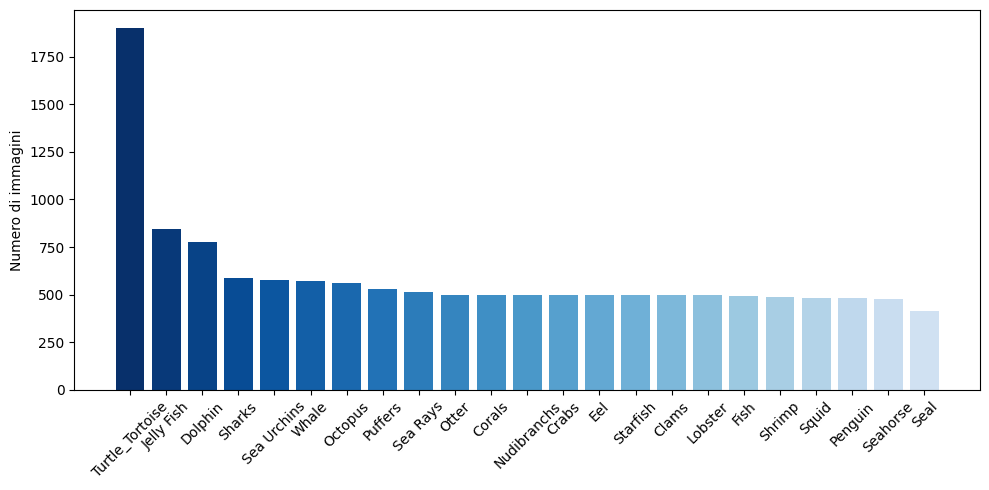

In [38]:
# Controllo bilanciamento dataset
# TBD : nella relazione la tabella andrà sotto la voce "Distribuzione immagini per classe"

dict_targets_NElements = {}

for directory in os.listdir(DATA_DIR):
    dict_targets_NElements[directory] = len(os.listdir(os.path.join(DATA_DIR, directory)))

# Ordino il dizionario in modo decrescente
dict_targets_NElements = dict(sorted(dict_targets_NElements.items(), key=lambda x: x[1], reverse=True))

# Creo palette di colori sulla base del numero di elementi del dizionario
colors = plt.cm.Blues(np.linspace(1, 0.2, len(dict_targets_NElements)))

# Grafico della distribuzuine immagini per classe
plt.figure(figsize=(10, 5))
plt.bar(dict_targets_NElements.keys(), dict_targets_NElements.values(), color=colors)
plt.xticks(rotation=45)
plt.ylabel("Numero di immagini")
plt.tight_layout()
plt.show()

In [48]:
# 80% train, 10% validation, 10% test
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split = 0.2,
    subset = "training",
    seed = 123,
    image_size = (224, 224),
    batch_size = 32
)

val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split = 0.2,
    subset = "validation",
    seed = 123,
    image_size = (224, 224),
    batch_size = 32
)

# Calcolo il numero di batch e le uso per dividere la seconda porzione del dataset
val_test_batches = tf.data.experimental.cardinality(val_test_ds)
val_ds = val_test_ds.take((val_test_batches) // 2)
test_ds = val_test_ds.skip((val_test_batches) // 2)

Found 13678 files belonging to 23 classes.
Using 10943 files for training.
Found 13678 files belonging to 23 classes.
Using 2735 files for validation.


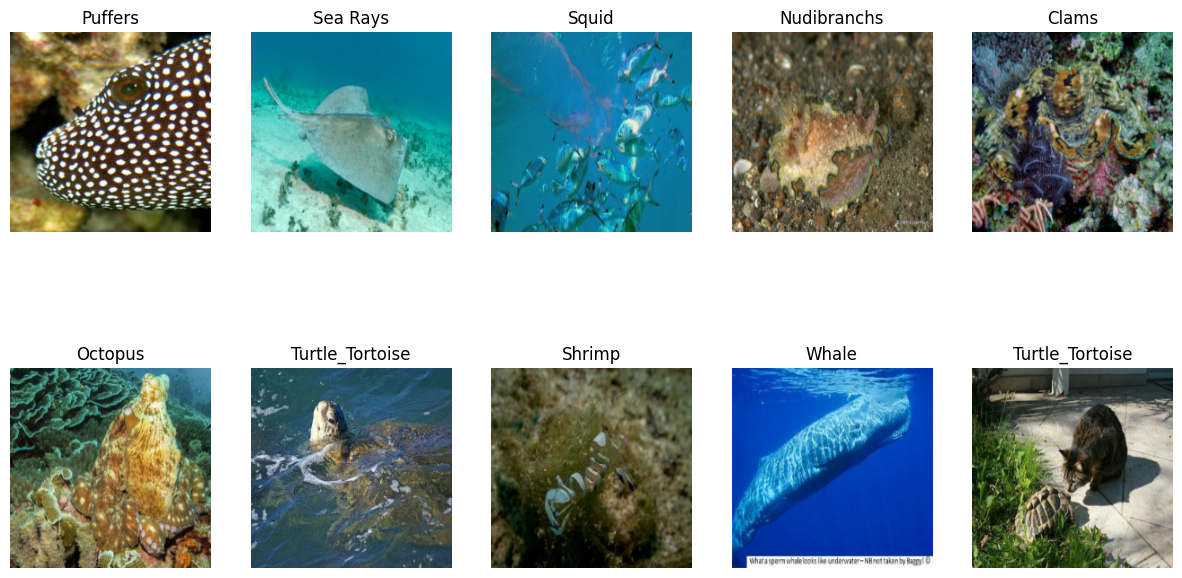

In [51]:
# Stampiamo a schermo i primi 10 elementi
images, labels = next(iter(train_ds))

class_names = train_ds.class_names

plt.figure(figsize=(15, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()